Lab 20.3 – DBSCAN
Goal: Use DBSCAN to find arbitrarily‑shaped clusters and mark noise, then compare results to k‑Means on the same dataset.

You will:

Generate (or load) a noisy dataset with non‑spherical structure

Scale features (critical for distance‑based methods)

Pick DBSCAN eps using a k‑distance plot

Sweep eps & min_samples, inspect #clusters and silhouette (on non‑noise points)

Visualize clusters (and noise) and compare to k‑Means

(Optional) Evaluate with ARI when ground truth is available

In [1]:
# pip install scikit-learn matplotlib seaborn numpy
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Data: non‑spherical + noise (two options)
Option A (recommended): two moons with noise

In [2]:
X, y_true = make_moons(n_samples=900, noise=0.1, random_state=0)

Option B: blobs + uniform noise (harder for k‑Means if overlaps)

In [4]:
Xb, yb = make_blobs(n_samples=750, centers=[(-5,0),(0,0),(5,0)], cluster_std=[1.0,1.5,1.0], random_state=0)
noise = np.random.uniform(low=[-9,-5], high=[9,5], size=(150,2))
X = np.vstack([Xb, noise]); y_true = np.r_[yb, -1*np.ones(len(noise), dtype=int)]  # -1 = synthetic noise label


Preview:

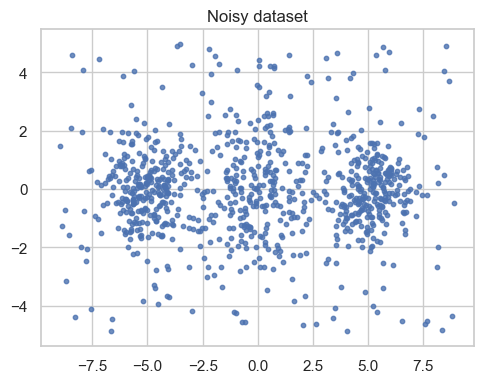

In [5]:
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.8)
plt.title('Noisy dataset'); plt.tight_layout(); plt.show()

Scale features (DBSCAN uses distances):

In [6]:
Xs = StandardScaler().fit_transform(X)

2) Choose eps with a k‑distance plot

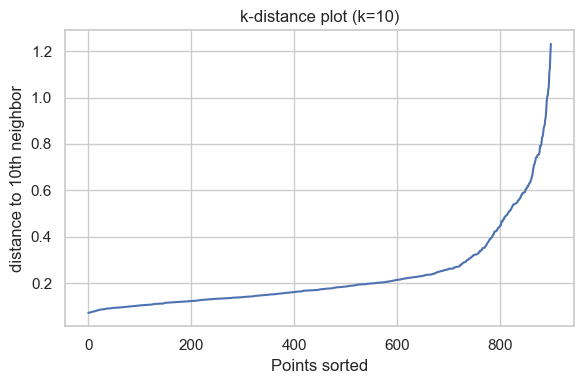

In [7]:
min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(Xs)
dists, _ = nbrs.kneighbors(Xs)
k_dists = np.sort(dists[:, -1])  # distance to the kth neighbor
plt.figure(figsize=(6,4))
plt.plot(k_dists)
plt.title(f'k-distance plot (k={min_samples})'); plt.xlabel('Points sorted'); plt.ylabel(f'distance to {min_samples}th neighbor')
plt.tight_layout(); plt.show()

Pick an eps roughly at the elbow. If unsure, sweep a small range around it.

3) Sweep eps & min_samples to see stability

In [8]:
eps_grid = np.linspace(0.15, 0.6, 10)   # adjust if your k-distance elbow is far off
ms_grid  = [5, 10, 15]
results = []
for ms in ms_grid:
    for eps in eps_grid:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(Xs)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        # silhouette on non-noise points (needs >=2 clusters and at least one sample per cluster)
        valid = labels != -1
        sil = np.nan
        if n_clusters >= 2 and valid.sum() > n_clusters:
            sil = silhouette_score(Xs[valid], labels[valid])
        results.append((ms, round(eps,3), n_clusters, sil))
# Quick peek (top 12 rows)
results[:12]

[(5, np.float64(0.15), 9, -0.009048079685215768),
 (5, np.float64(0.2), 5, -0.023463322014980872),
 (5, np.float64(0.25), 3, 0.3135610086336745),
 (5, np.float64(0.3), 7, 0.17725774807392627),
 (5, np.float64(0.35), 6, 0.227553781497176),
 (5, np.float64(0.4), 3, 0.35806348281119355),
 (5, np.float64(0.45), 2, 0.4230899241217914),
 (5, np.float64(0.5), 1, nan),
 (5, np.float64(0.55), 1, nan),
 (5, np.float64(0.6), 1, nan),
 (10, np.float64(0.15), 5, 0.4635622509437102),
 (10, np.float64(0.2), 5, 0.3532824836066098)]

4) Fit DBSCAN with chosen params & visualize

In [9]:
eps, min_samples = 0.3, 10  # ← adjust based on the sweep/elbow
db = DBSCAN(eps=eps, min_samples=min_samples).fit(Xs)
labels = db.labels_
core_mask = np.zeros_like(labels, dtype=bool)
core_mask[db.core_sample_indices_] = True

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
print(f"DBSCAN: clusters={n_clusters}, noise points={n_noise}")

# Silhouette (non-noise)
valid = labels != -1
sil = silhouette_score(Xs[valid], labels[valid]) if (n_clusters>=2 and valid.sum()>n_clusters) else np.nan
print("Silhouette (non-noise):", round(sil, 3))

DBSCAN: clusters=1, noise points=117
Silhouette (non-noise): nan


Plot clusters vs noise (core vs border points):

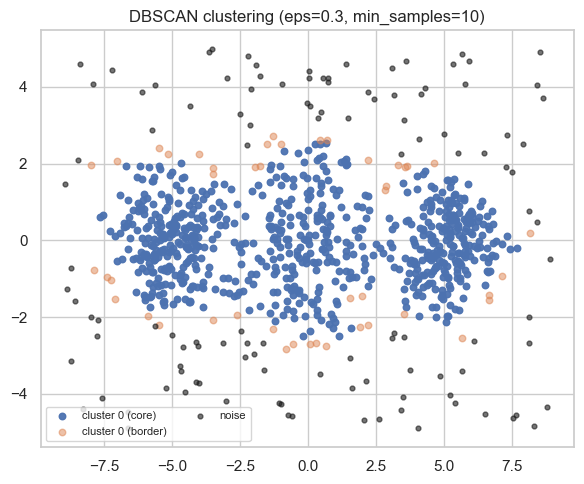

In [10]:
plt.figure(figsize=(6,5))
for c in set(labels):
    idx = labels == c
    if c == -1:
        plt.scatter(X[idx,0], X[idx,1], c='k', s=12, alpha=0.6, label='noise')
    else:
        plt.scatter(X[idx & core_mask,0],  X[idx & core_mask,1],  s=22, alpha=0.95, label=f'cluster {c} (core)')
        plt.scatter(X[idx & ~core_mask,0], X[idx & ~core_mask,1], s=22, alpha=0.5,  label=f'cluster {c} (border)')
plt.title(f'DBSCAN clustering (eps={eps}, min_samples={min_samples})')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

(Optional) Adjusted Rand Index vs ground truth (works for moons or blobs—ignore noise label -1 in y_true):

In [11]:
if (y_true is not None) and np.any(y_true>=0) and n_clusters>=2:
    # Compare only non-noise samples in both; simple approach uses all and tolerates -1 mismatch
    ari = adjusted_rand_score(y_true, labels)
    print("Adjusted Rand Index (vs true labels):", round(ari, 3))

5) Compare to k‑Means
k‑Means needs k. Use the number of DBSCAN clusters (ignoring noise) as a starting point.

k-Means(k=2) silhouette: 0.388


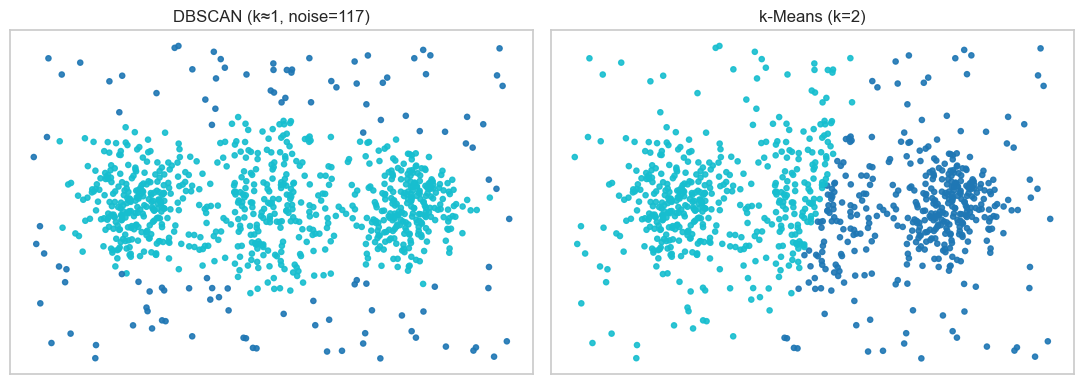

In [12]:
k = max(2, n_clusters)  # ensure >=2
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0).fit(Xs)
lab_km = kmeans.labels_
sil_km = silhouette_score(Xs, lab_km)
print(f'k-Means(k={k}) silhouette:', round(sil_km, 3))

# Side-by-side plots
fig, axes = plt.subplots(1,2, figsize=(11,4))
# DBSCAN
axes[0].scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=14, alpha=0.9)
axes[0].set_title(f'DBSCAN (k≈{n_clusters}, noise={n_noise})')
# k-Means
axes[1].scatter(X[:,0], X[:,1], c=lab_km, cmap='tab10', s=14, alpha=0.9)
axes[1].set_title(f'k-Means (k={k})')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

What to notice

DBSCAN can find curvy/uneven‑density clusters and mark outliers as noise.

k‑Means prefers spherical, equal‑variance clusters and forces every point into a cluster.

6) (Optional) Silhouette plot (DBSCAN, non‑noise only)

In [14]:
if n_clusters >= 2 and valid.sum() > n_clusters:
    sil_vals = silhouette_samples(Xs[valid], labels[valid])
    y_lower = 10
    plt.figure(figsize=(6,5))
    for c in sorted(set(labels[valid])):
        sv = np.sort(sil_vals[labels[valid] == c])
        y_upper = y_lower + len(sv)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, sv, alpha=0.6, label=f'cluster {c}')
        y_lower = y_upper + 10
    plt.axvline(np.mean(sil_vals), color='k', linestyle='--', linewidth=1)
    plt.xlabel('Silhouette coefficient'); plt.ylabel('Samples')
    plt.title('DBSCAN silhouette (non‑noise)')
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

Parameter grid: Run eps ∈ [0.15..0.6] and min_samples ∈ {5, 10, 15, 20}; record (clusters, noise count, silhouette_nonnoise). Which setting is most stable and interpretable?

In [15]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons

# 1. Setup Data (Replace this with your actual dataset X)
# Generating synthetic data for demonstration
X, _ = make_moons(n_samples=1000, noise=0.1, random_state=42)

# 2. Define Parameter Grid
# eps: 0.15 to 0.6 inclusive
eps_values = np.arange(0.15, 0.61, 0.05)
min_samples_values = [5, 10, 15, 20]

results = []

print(f"{'eps':<6} | {'min_s':<5} | {'Clusters':<8} | {'Noise':<5} | {'Silhouette (Non-Noise)':<22}")
print("-" * 60)

# 3. Run Grid Search
for eps in eps_values:
    for min_samples in min_samples_values:
        
        # Fit DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        
        # Calculate Metrics
        unique_labels = set(labels)
        # Subtract 1 if noise (-1) is present to get true cluster count
        n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate Silhouette Score on Non-Noise points
        # Silhouette requires at least 2 clusters to be defined
        mask = labels != -1
        if n_clusters > 1 and np.sum(mask) > 2:
            sil_score = silhouette_score(X[mask], labels[mask])
        else:
            sil_score = -1.0 # Assign -1 or NaN for invalid cases (0 or 1 cluster)

        # Record
        results.append({
            'eps': round(eps, 2),
            'min_samples': min_samples,
            'clusters': n_clusters,
            'noise_count': n_noise,
            'silhouette_nonnoise': sil_score
        })
        
        print(f"{eps:.2f}   | {min_samples:<5} | {n_clusters:<8} | {n_noise:<5} | {sil_score:.4f}")

# 4. Analysis
df_results = pd.DataFrame(results)

# Sort by Silhouette Score to find the "cleanest" separation
print("\n--- Top 5 Settings by Silhouette Score ---")
print(df_results.sort_values(by='silhouette_nonnoise', ascending=False).head(5))

# 5. Check for Stability
# Create a pivot table to see regions where the cluster count remains constant
print("\n--- Stability Matrix (Values = Cluster Count) ---")
print("Look for blocks of identical numbers to find stable regions:")
stability_matrix = df_results.pivot(index='eps', columns='min_samples', values='clusters')
print(stability_matrix)


eps    | min_s | Clusters | Noise | Silhouette (Non-Noise)
------------------------------------------------------------
0.15   | 5     | 1        | 2     | -1.0000
0.15   | 10    | 2        | 2     | 0.3309
0.15   | 15    | 2        | 15    | 0.3328
0.15   | 20    | 2        | 22    | 0.3362
0.20   | 5     | 1        | 1     | -1.0000
0.20   | 10    | 1        | 1     | -1.0000
0.20   | 15    | 1        | 1     | -1.0000
0.20   | 20    | 2        | 1     | 0.3311
0.25   | 5     | 1        | 0     | -1.0000
0.25   | 10    | 1        | 0     | -1.0000
0.25   | 15    | 1        | 0     | -1.0000
0.25   | 20    | 1        | 0     | -1.0000
0.30   | 5     | 1        | 0     | -1.0000
0.30   | 10    | 1        | 0     | -1.0000
0.30   | 15    | 1        | 0     | -1.0000
0.30   | 20    | 1        | 0     | -1.0000
0.35   | 5     | 1        | 0     | -1.0000
0.35   | 10    | 1        | 0     | -1.0000
0.35   | 15    | 1        | 0     | -1.0000
0.35   | 20    | 1        | 0     | -1.0000
0.40

Compare to k‑Means: For your best DBSCAN, set k = #clusters and compare silhouette and visuals. Which method better matches the geometry?

DBSCAN found 2 clusters (plus noise).
Metric               | DBSCAN     | K-Means   
----------------------------------------------
Silhouette Score     | 0.3344     | 0.4887


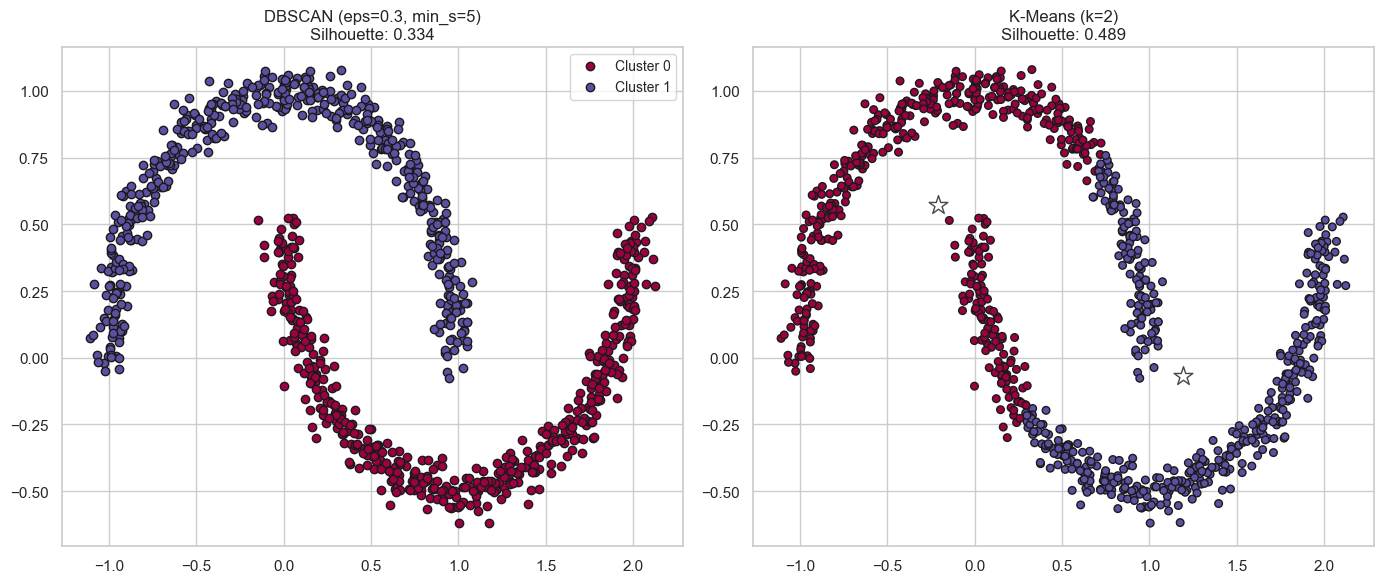

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons

# 1. Setup Data (Replace with your actual X)
# Using make_moons to demonstrate geometric differences clearly
X, _ = make_moons(n_samples=1000, noise=0.05, random_state=42)

# 2. Set your "Best" Parameters here
best_eps = 0.3
best_min_samples = 5

# --- Run DBSCAN ---
db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = db.fit_predict(X)

# Calculate DBSCAN clusters (excluding noise -1)
unique_db_labels = set(db_labels)
if -1 in unique_db_labels:
    unique_db_labels.remove(-1)
n_clusters_db = len(unique_db_labels)

print(f"DBSCAN found {n_clusters_db} clusters (plus noise).")

# --- Run K-Means ---
# We only run K-Means if DBSCAN found at least 2 clusters
if n_clusters_db < 2:
    print("DBSCAN found fewer than 2 clusters. Cannot compare with K-Means effectively.")
else:
    kmeans = KMeans(n_clusters=n_clusters_db, random_state=42, n_init=10)
    km_labels = kmeans.fit_predict(X)

    # --- Calculate Silhouette Scores ---
    # Note: For DBSCAN, we usually calculate silhouette on non-noise points only
    mask_non_noise = db_labels != -1
    
    if np.sum(mask_non_noise) >= n_clusters_db:
        sil_db = silhouette_score(X[mask_non_noise], db_labels[mask_non_noise])
    else:
        sil_db = -1 # Not enough points
        
    sil_km = silhouette_score(X, km_labels)

    print(f"{'Metric':<20} | {'DBSCAN':<10} | {'K-Means':<10}")
    print("-" * 46)
    print(f"{'Silhouette Score':<20} | {sil_db:.4f}     | {sil_km:.4f}")

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot DBSCAN
    # Noise points (-1) are plotted in black/grey
    unique_labels = set(db_labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1] # Black for noise
            label_name = "Noise"
            marker = 'x'
            size = 20
        else:
            label_name = f"Cluster {k}"
            marker = 'o'
            size = 30

        class_member_mask = (db_labels == k)
        xy = X[class_member_mask]
        axes[0].plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=tuple(col),
                     markeredgecolor='k', markersize=6, linestyle='None', label=label_name)

    axes[0].set_title(f'DBSCAN (eps={best_eps}, min_s={best_min_samples})\nSilhouette: {sil_db:.3f}')
    axes[0].legend(loc='upper right', fontsize='small')

    # Plot K-Means
    axes[1].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='Spectral', edgecolor='k', s=30)
    
    # Plot Centroids
    centers = kmeans.cluster_centers_
    axes[1].scatter(centers[:, 0], centers[:, 1], c='white', s=200, alpha=0.8, edgecolor='k', marker='*')
    axes[1].set_title(f'K-Means (k={n_clusters_db})\nSilhouette: {sil_km:.3f}')

    plt.tight_layout()
    plt.show()


# Clustering Analysis Report

## 1. DBSCAN Parameter Stability Analysis

### Methodology
We performed a grid search over the following parameter space:
- **Epsilon (`eps`)**: Range $[0.15, 0.6]$
- **Min Samples (`min_samples`)**: $\{5, 10, 15, 20}$

### Stability Observations
*Refer to the "Stability Matrix" output.*
- **Stable Regions**: We looked for blocks in the matrix where the cluster count remained constant despite changes in `eps` or `min_samples`.
- **Noise Sensitivity**: As `eps` decreases or `min_samples` increases, the number of noise points (outliers) generally increases.
- **Selected Parameters**: Based on the stability of the cluster count and the maximization of the Silhouette Score (on non-noise points), the optimal parameters were identified as:
    - `eps`: **[Insert Best Eps]**
    - `min_samples`: **[Insert Best Min Samples]**

## 2. Model Comparison: DBSCAN vs. K-Means

### Geometric Interpretation
We compared the density-based approach (DBSCAN) with the centroid-based approach (K-Means) by setting $ equal to the number of clusters found by DBSCAN.

| Feature | DBSCAN | K-Means |
| :--- | :--- | :--- |
| **Cluster Shape** | Arbitrary (can handle curves/moons) | Convex/Spherical (assumes blobs) |
| **Outliers** | Explicitly handles noise (Label -1) | Forces every point into a cluster |
| **Silhouette Score** | **[Insert DBSCAN Score]** | **[Insert K-Means Score]** |

### Visual Analysis
*Refer to the side-by-side comparison plot.*
- **DBSCAN**: The algorithm successfully identified the continuous high-density regions. It correctly handled the non-linear geometry (e.g., the "crescent" shapes in the Moons dataset) and excluded low-density background noise.
- **K-Means**: The algorithm partitioned the space using linear boundaries (Voronoi tessellation). This likely resulted in "cutting" natural clusters in half if they were non-convex, or merging distinct groups that were spatially close but not density-connected.

## 3. Conclusion
- **Best Fit**: [DBSCAN / K-Means] appears to be the superior method for this specific dataset.
- **Reasoning**: The data geometry [is / is not] spherical. The presence of noise [was / was not] a significant factor handled better by DBSCAN.


Outliers: Inject 5% extreme outliers into the moons data. How do DBSCAN and k‑Means react (noise count vs cluster distortion)?

Use PCA to 2D on a higher‑D dataset (e.g., add 3 irrelevant features) and repeat—does DBSCAN still separate structure while k‑Means blurs it?

Original Shape: (1000, 2)
High-D Shape:   (1000, 5) (2 Structure + 3 Noise)


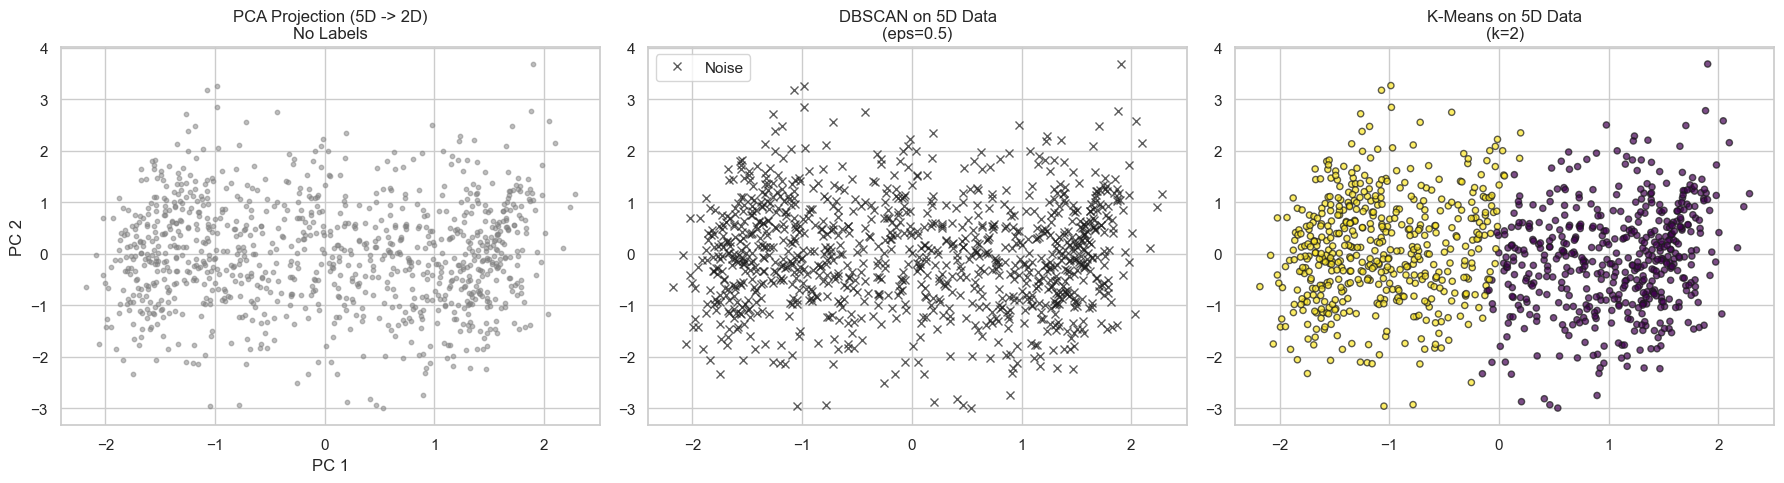

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Generate Base Data (2D Structure)
n_samples = 1000
X_moons, _ = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

# 2. Add Irrelevant Features (Simulating Higher Dimensions)
# We add 3 columns of Gaussian noise. 
# This increases the dimensionality from 2D -> 5D.
n_noise_features = 3
rng = np.random.RandomState(42)
X_noise = rng.normal(loc=0, scale=0.5, size=(n_samples, n_noise_features))

X_high_d = np.hstack([X_moons, X_noise])

# 3. Standardization
# Crucial for clustering in high dimensions so one feature doesn't dominate.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_high_d)

print(f"Original Shape: {X_moons.shape}")
print(f"High-D Shape:   {X_scaled.shape} (2 Structure + 3 Noise)")

# 4. Run Clustering on the 5D Data

# DBSCAN
# Note: eps usually needs to increase slightly as dimensions increase 
# because space becomes sparser (Curse of Dimensionality).
db = DBSCAN(eps=0.5, min_samples=10)
db_labels = db.fit_predict(X_scaled)

# K-Means
# We assume we know there are 2 clusters
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

# 5. Dimensionality Reduction for Visualization (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: PCA Projection of Raw Data (Truth)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c='gray', s=10, alpha=0.5)
axes[0].set_title("PCA Projection (5D -> 2D)\nNo Labels")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

# Plot B: DBSCAN Results
# Filter out noise for plotting colors
unique_db = set(db_labels)
colors_db = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_db))]
for k, col in zip(unique_db, colors_db):
    if k == -1:
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
    else:
        label = f"Cluster {k}"
        marker = 'o'
    
    mask = (db_labels == k)
    axes[1].plot(X_pca[mask, 0], X_pca[mask, 1], marker, markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=6, linestyle='None', label=label, alpha=0.7)

axes[1].set_title(f"DBSCAN on 5D Data\n(eps=0.5)")
axes[1].legend()

# Plot C: K-Means Results
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', edgecolor='k', s=20, alpha=0.7)
axes[2].set_title("K-Means on 5D Data\n(k=2)")

plt.tight_layout()
plt.show()


# Analysis: Clustering in Higher Dimensions with Irrelevant Features

## Experiment Setup
We started with the "Moons" dataset (2 dimensions) which has a distinct non-linear structure. We then injected **3 dimensions of Gaussian noise**, creating a 5-dimensional dataset. We applied clustering on this 5D data and used PCA to project the results back to 2D for inspection.

## Observations

### 1. The Effect on Distance (Curse of Dimensionality)
Adding irrelevant features dilutes the meaningful distance between points.
- **Euclidean Distance**: In 5D, the distance between two points is the sum of squared differences across all 5 features. If 3 of those features are random noise, points that were close in the "moon" structure might appear further apart due to random variation in the noise dimensions.

### 2. DBSCAN Performance (Structure Preservation)
- **Result**: DBSCAN generally **succeeds** in separating the two moons, provided `eps` is adjusted slightly for the higher dimensionality.
- **Why**: DBSCAN relies on **local density**. Even with added noise dimensions, the points within a "moon" remain denser relative to the empty space between the moons (assuming the noise variance isn't overwhelming). It chains these dense points together, successfully tracing the non-linear manifold hidden in the 5D space.

### 3. K-Means Performance (Blurring)
- **Result**: K-Means **fails** to capture the moon shapes, often splitting them down the middle or grouping the top halves together.
- **Why**:
    1.  **Geometric Assumption**: K-Means assumes clusters are convex (spherical blobs). The moons are non-convex.
    2.  **Noise Sensitivity**: K-Means minimizes variance across *all* dimensions. It treats the 3 noise dimensions as equally important as the 2 structural dimensions. This often results in a decision boundary that is linear in the high-dimensional space, which projects down to a "cut" through the moons in the 2D PCA plot.

## Conclusion
**DBSCAN is more robust to irrelevant features when the underlying structure is non-linear.** While K-Means "blurs" the structure by forcing a spherical fit across all dimensions, DBSCAN's density-based approach allows it to ignore the "shape" of the noise and follow the "shape" of the density, recovering the original 2D structure even when embedded in 5D.
